In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind, ttest_rel, levene
from scipy.stats import t, norm
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

import numpy as np
import scipy.stats as st

%matplotlib inline

In [ ]:
data = pd.read_csv('data_ab.csv')
data

,user_id,timestamp,group,landing_page,converted
0,851104,2025-01-21 22:11:48.556739,control,old_page,0
1,804228,2025-01-12 08:01:45.159739,control,old_page,0
2,661590,2025-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2025-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2025-01-21 01:52:26.210827,control,old_page,1
...,...,...,...,...,...
294473,751197,2025-01-03 22:28:38.630509,control,old_page,0
294474,945152,2025-01-12 00:51:57.078372,control,old_page,0
294475,734608,2025-01-22 11:45:03.439544,control,old_page,0
294476,697314,2025-01-15 01:20:28.957438,control,old_page,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [ ]:
data.isna().any().any()

np.False_

В датасете нет пропусков

Приведем `timestamp` к правильному типу данных

In [ ]:
data['timestamp'] = pd.to_datetime(data['timestamp'], errors='coerce')

## Univariate analysis

### `id`

In [ ]:
unique_users = data['user_id'].nunique()
unique_users

290584

In [ ]:
data.shape[0]

294478

In [ ]:
data['user_id'].nunique() / data.shape[0] * 100

98.67766013080774

98.7% строк уникальны

In [ ]:
data['user_id'].value_counts().sort_values(ascending=False).head(5)

,count
user_id,
822618,2
904418,2
879483,2
888039,2
737298,2


Видим, что есть пользователи, которые встречаются по несколько раз, но более двух раз пользователи не повторяются.

Из того, что почти все айди - уникальны, и повторы всего по два раза максимум, можно сделать вывод: повторные показы скорее всего ошибка, они не должны учитываться в анализе. Рассмотрим повторы подробнее и почистим датасет.

### `landing_page`

In [ ]:
data['landing_page'].value_counts()

,count
landing_page,
old_page,147239
new_page,147239


In [ ]:
data['group'].value_counts()

,count
group,
treatment,147276
control,147202


Удивительно, но тут показов ровно поровну. Хотя в группах разное кол-во людей. Значит точно что-то не сходится и это требует проверки

### Preparing data

Видим, что есть пользователи, окторые встречаются по несколько раз. Проверим, есть ли пользователи, которые **видят и `old_page`, и `new_page`**.

In [ ]:
page_per_user = data.groupby('user_id')['landing_page'].nunique() # сколько разных лендингов видел каждый пользователь
users_multi_page = page_per_user[page_per_user > 1].index

len(users_multi_page)

1998

Таких пользователей, которые видят и `old_page`, и `new_page` - 1998.

 Проверим, есть ли пользователи, которые находятся **и в группе `control`, и в `treatment`**.

In [ ]:
group_per_user = data.groupby('user_id')['group'].nunique() # сколько разных групп у каждого пользователя
users_multi_group = group_per_user[group_per_user > 1].index

len(users_multi_group)

1895

Таких пользователей - 1895.

In [ ]:
print(f'Процент пользователей, которые видят и новую, и старую страницу:', f'({len(users_multi_page) / unique_users:.2%})')
print('Процент пользователей, которые находятся сразу в двух группах:',  f'({len(users_multi_group) / unique_users:.2%})')

Процент пользователей, которые видят и новую, и старую страницу: (0.69%)
Процент пользователей, которые находятся сразу в двух группах: (0.65%)


Видим, что есть пользователи, которые видят и новую, и старую страницу одновременно. А также есть пользователи, которые находятся в двух группах одновременно. Однако доля таких людей очень мала относительно всех пользователей.

In [ ]:
problem_users = set(users_multi_page) | set(users_multi_group)
print('Всего проблемных пользователей:', len(problem_users), f'({len(problem_users) / unique_users:.2%})')

Всего проблемных пользователей: 3893 (1.34%)


Оставим самые ранние записи у проблемных пользователей, чтобы смотреть на них сразу после распределения, мы считаем их приписанными к этому варианту, даже если потом они увидел что-то ещё из-за бага.

In [ ]:
data_sorted = data.sort_values(['user_id', 'timestamp'])
first_visit = data_sorted.drop_duplicates(subset="user_id", keep="first").copy()

Также проверим, что совпадают `group` и `landing_page` (`treatment` - `new_page`, `control` - `old_page`)

In [ ]:
mask_valid = (((first_visit['group'] == 'control') & (first_visit['landing_page'] == 'old_page')) |((first_visit['group'] == 'treatment') & (first_visit['landing_page'] == 'new_page')))
data_clean = first_visit[mask_valid].copy()
data_clean

,user_id,timestamp,group,landing_page,converted
63114,630000,2025-01-19 06:26:06.548941,treatment,new_page,0
103873,630001,2025-01-16 03:16:42.560309,treatment,new_page,1
205236,630002,2025-01-19 19:20:56.438330,control,old_page,0
247344,630003,2025-01-12 10:09:31.510471,treatment,new_page,0
242283,630004,2025-01-18 20:23:58.824994,treatment,new_page,0
...,...,...,...,...,...
274312,945994,2025-01-03 14:41:21.565258,control,old_page,0
275777,945996,2025-01-09 18:58:19.952277,treatment,new_page,0
109353,945997,2025-01-04 06:56:24.658147,control,old_page,0
241062,945998,2025-01-16 07:08:02.207969,control,old_page,0


**Проверка**

In [ ]:
data_clean[(data_clean['group'] == 'control') & (data_clean['landing_page'] != 'old_page')]

,user_id,timestamp,group,landing_page,converted


In [ ]:
data_clean[(data_clean['group'] == 'treatment') & (data_clean['landing_page'] != 'new_page')]

,user_id,timestamp,group,landing_page,converted


### `group`

In [ ]:
data_clean['group'].value_counts()

,count
group,
control,144319
treatment,144316


In [ ]:
data_clean['group'].value_counts(normalize=True)

,proportion
group,
control,0.500005
treatment,0.499995


Как видно, группы остались очень сбалансированными.

### `timestamp`

In [ ]:
data_clean['timestamp'].describe()

,timestamp
count,288635
mean,2025-01-13 13:05:20.392675072
min,2025-01-02 13:42:05.378582
25%,2025-01-08 01:25:10.110609920
50%,2025-01-13 12:24:48.310561024
75%,2025-01-19 01:11:56.032314368
max,2025-01-24 13:41:54.460509


In [ ]:
start = data_clean['timestamp'].min()
end = data_clean['timestamp'].max()
duration = end - start

print('Начало теста:', start)
print('Конец теста:', end)
print('Длительность теста:', duration)

Начало теста: 2025-01-02 13:42:05.378582
Конец теста: 2025-01-24 13:41:54.460509
Длительность теста: 21 days 23:59:49.081927


То есть, эксперимент проводился с 2 января 2025 по 24 января 2025. Это 3 недели, оптимальное время для проведения A/B теста

<Axes: xlabel='timestamp'>

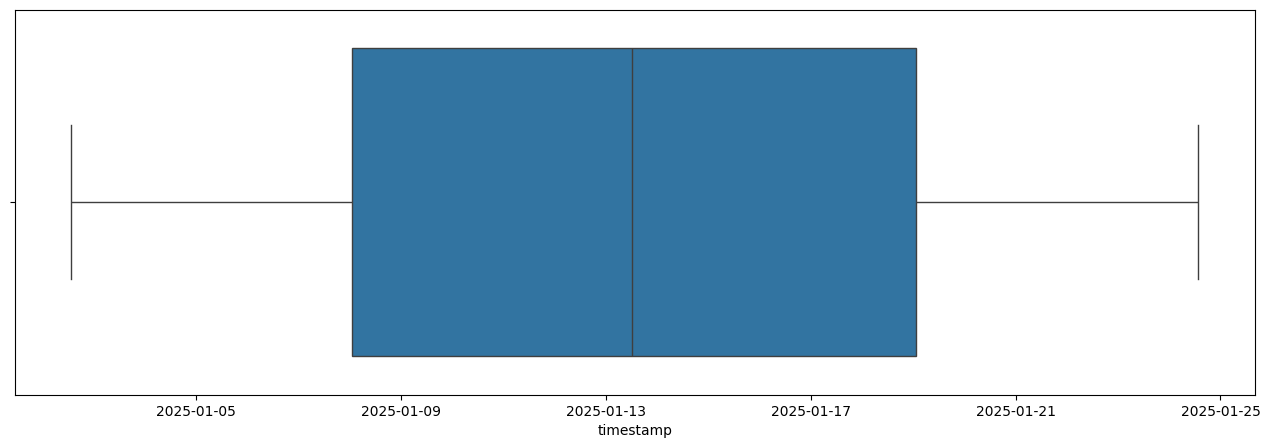

In [ ]:
plt.figure(figsize=(16,5))
sns.boxplot(x=data_clean['timestamp'])

<Axes: xlabel='timestamp', ylabel='Count'>

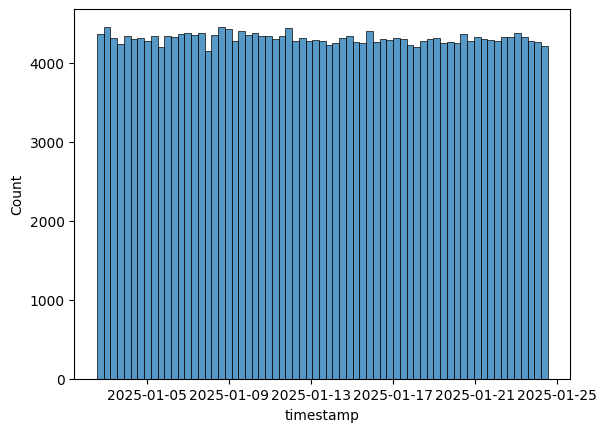

In [ ]:
sns.histplot(data_clean['timestamp'])

Cтобцы примерно равномерненые.

Мы видим, что эксперимент проводился в течение 23 дней, с 2 января 2025 по 24 января 2025, чуть больше трех недель. Пока что все хорошо и скорее всего, согласуется с дизайном эксперимента

### Анализ трафика

In [ ]:
data_clean['date'] = data_clean['timestamp'].dt.date
data_clean['hour'] = data_clean['timestamp'].dt.hour
data_clean

,user_id,timestamp,group,landing_page,converted,date,hour
63114,630000,2025-01-19 06:26:06.548941,treatment,new_page,0,2025-01-19,6
103873,630001,2025-01-16 03:16:42.560309,treatment,new_page,1,2025-01-16,3
205236,630002,2025-01-19 19:20:56.438330,control,old_page,0,2025-01-19,19
247344,630003,2025-01-12 10:09:31.510471,treatment,new_page,0,2025-01-12,10
242283,630004,2025-01-18 20:23:58.824994,treatment,new_page,0,2025-01-18,20
...,...,...,...,...,...,...,...
274312,945994,2025-01-03 14:41:21.565258,control,old_page,0,2025-01-03,14
275777,945996,2025-01-09 18:58:19.952277,treatment,new_page,0,2025-01-09,18
109353,945997,2025-01-04 06:56:24.658147,control,old_page,0,2025-01-04,6
241062,945998,2025-01-16 07:08:02.207969,control,old_page,0,2025-01-16,7


Добавим столбцы с датой и временем.

**Сколько людей в день**

In [ ]:
daily_counts = (
    data_clean
    .groupby('date')['user_id']
    .nunique()
    .reset_index(name='users_per_day')
)

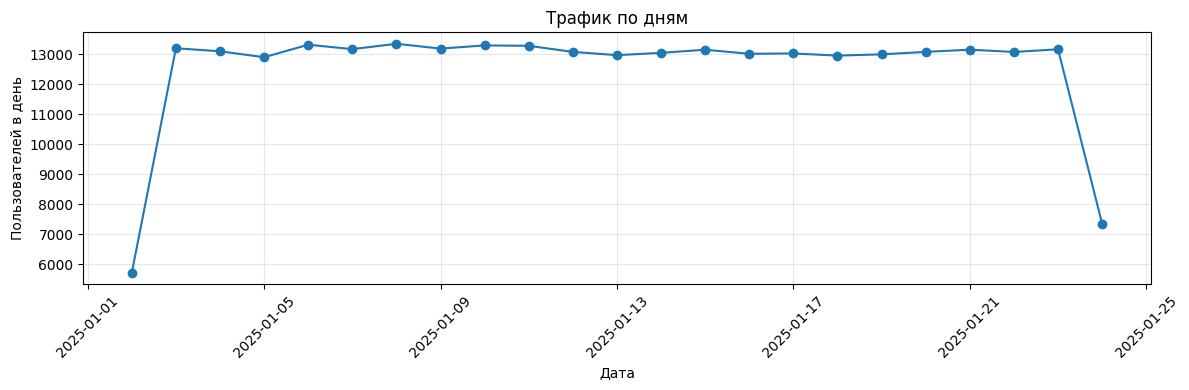

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(daily_counts["date"], daily_counts["users_per_day"], marker="o")
plt.title("Трафик по дням")
plt.xlabel("Дата")
plt.ylabel("Пользователей в день")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Сколько людей в день по группам

In [ ]:
daily_counts_by_group = (
    data_clean
    .groupby(['date', 'group'])['user_id']
    .nunique()
    .unstack('group')
    .fillna(0)
)

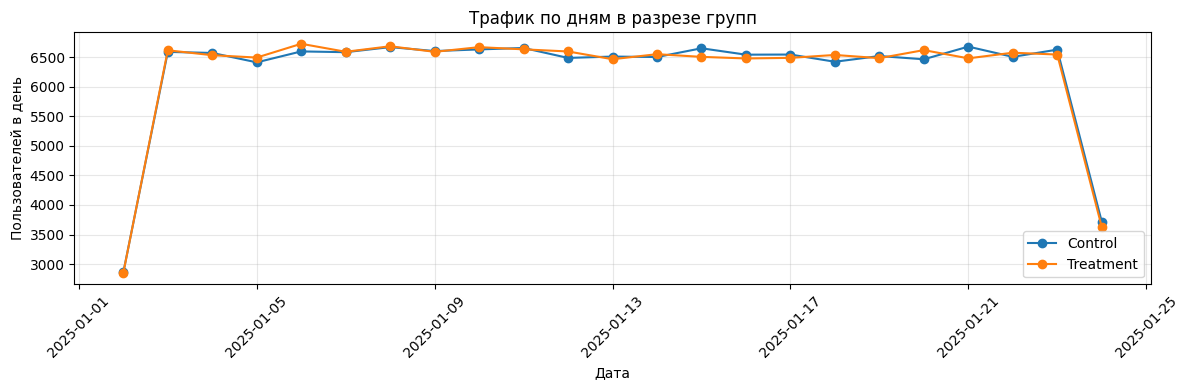

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(daily_counts_by_group.index, daily_counts_by_group["control"], marker="o", label="Control")
plt.plot(daily_counts_by_group.index, daily_counts_by_group["treatment"], marker="o", label="Treatment")

plt.title("Трафик по дням в разрезе групп")
plt.xlabel("Дата")
plt.ylabel("Пользователей в день")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Видно, что в первый и последний день тестирования самый маленький трафик. На протяжении тестирования количество людей в день в обеих группах было примерно равно 6500

Трафик по часам

In [ ]:
hourly_counts = (
    data_clean
    .groupby('hour')['user_id']
    .nunique()
    .reset_index(name='users_per_hour')
)

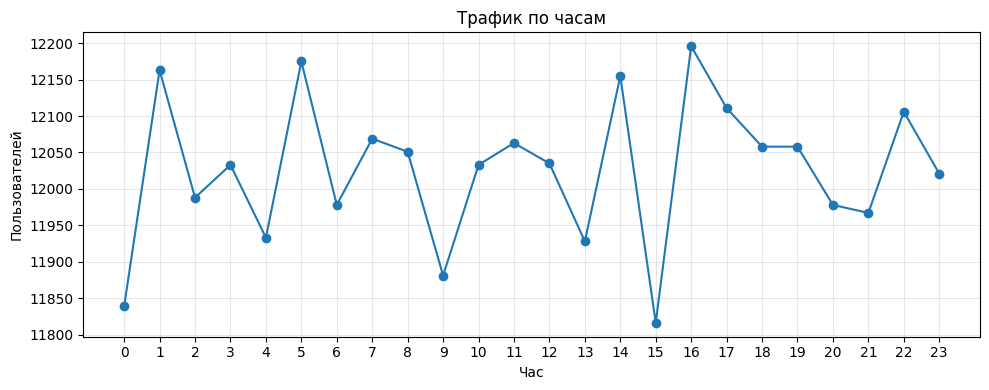

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(hourly_counts["hour"], hourly_counts["users_per_hour"], marker="o")
plt.title("Трафик по часам")
plt.xlabel("Час")
plt.ylabel("Пользователей")
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Трафик по часам распределён достаточно равномерно: в течение суток нет выраженного пикового времени. Наблюдаются лишь небольшие колебания, но в целом уровень остаётся стабильным.

### `converted`

In [ ]:
data_clean['converted'].value_counts(normalize=True)

,proportion
converted,
0,0.880455
1,0.119545


In [ ]:
daily_conv = (
    data_clean
    .groupby(['date', 'group'])['converted']
    .mean()
    .unstack('group')
)

daily_conv

group,control,treatment
date,,
2025-01-02,0.125568,0.119874
2025-01-03,0.113692,0.113832
2025-01-04,0.121918,0.116810
2025-01-05,0.123538,0.115219
2025-01-06,0.115221,0.123123
2025-01-07,0.120918,0.116237
2025-01-08,0.119058,0.120904
2025-01-09,0.119509,0.118379
2025-01-10,0.113122,0.126425


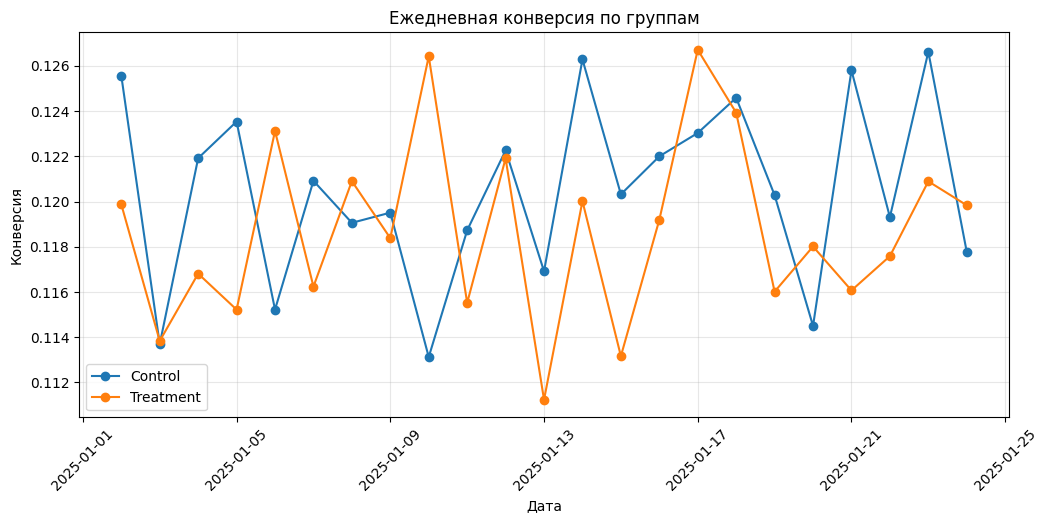

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(daily_conv.index, daily_conv["control"], label="Control", marker='o')
plt.plot(daily_conv.index, daily_conv["treatment"], label="Treatment", marker='o')

plt.title("Ежедневная конверсия по группам")
plt.xlabel("Дата")
plt.ylabel("Конверсия")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.show()

Конверсия по часам

In [ ]:
hourly_conv = (
    data_clean
    .groupby(['hour', 'group'])['converted']
    .mean()
    .unstack('group')
)

hourly_conv

group,control,treatment
hour,,
0,0.120654,0.120248
1,0.116234,0.111111
2,0.113693,0.113701
3,0.114091,0.114600
4,0.121005,0.107511
5,0.123703,0.118119
6,0.127642,0.114425
7,0.119479,0.115981
8,0.117454,0.120235


По часам нет какого-то пика конверсии

In [ ]:
median_ts = data_clean['timestamp'].median()
print('Медианный timestamp:', median_ts)

early = data_clean[data_clean['timestamp'] <= median_ts]
late  = data_clean[data_clean['timestamp'] > median_ts]

print('Размер первой половины:', early.shape[0], 'второй половины:', late.shape[0])

print('Конверсия по группам в первой половине:')
print(early.groupby('group')['converted'].mean())

print('\nКонверсия по группам во второй половине:')
print(late.groupby('group')['converted'].mean())

Медианный timestamp: 2025-01-13 12:24:48.310561024
Размер первой половины: 144318 второй половины: 144317
Конверсия по группам в первой половине:
group
control      0.118986
treatment    0.118532
Name: converted, dtype: float64

Конверсия по группам во второй половине:
group
control      0.121794
treatment    0.118864
Name: converted, dtype: float64


Видим, что конверсия примерно одинаковая все время. Только во второй половине в контрольной группе больше на одну сотую.

### MDE

In [ ]:
summary_n = (
    data_clean
    .groupby("group")["converted"]
    .agg(conversions="sum", users="count", cr="mean")
)

summary_n

,conversions,users,cr
group,,,
control,17375,144319,0.120393
treatment,17130,144316,0.118698


In [ ]:
p0 = summary_n.loc["control", "cr"] # базовая конверсия в контрольной группе
n_control = summary_n.loc["control", "users"] # размер выборки в контрольной группе
n_treat = summary_n.loc["treatment", "users"] # размер выборки в экспериментальной группе
n = min(n_control, n_treat) # эффективный размер каждой группы ≈ меньшей из двух

print("Базовая конверсия контрольной группы:", p0)
print("Размер группы:", n)

Базовая конверсия контрольной группы: 0.12039301824430601
Размер группы: 144316


In [ ]:
alpha = 0.05 # выбранный уровень значимости теста
z = norm.ppf(1 - alpha/2) # критическое значение z для двустороннего теста

mde_abs = np.sqrt(2 * (z**2) * p0 * (1 - p0) / n) # в долях
mde_pp  = mde_abs * 100 # в процентах

print("MDE в долях:", mde_abs)
print("MDE в процентах:", mde_pp)

MDE в долях: 0.0023743833184614056
MDE в процентах: 0.23743833184614055


Считаем длительность теста по формуле из лекции

In [ ]:
daily_users = (
    data_clean
    .groupby(["date", "group"])["user_id"]
    .nunique()
    .groupby("group")
    .mean()
)

daily_users

,user_id
group,
control,6274.739130
treatment,6274.608696


In [ ]:
daily_control = daily_users["control"]
days_from_formula = n / daily_control

print("Оценка длительности по формуле:", days_from_formula, "дней")

Оценка длительности по формуле: 22.99952189247431 дней


Ранее мы смотрели, что фактическая длительность тестирования 22 дня. Значит, тестирование проведено корреткно.

## Multivariate

<Axes: xlabel='timestamp', ylabel='Count'>

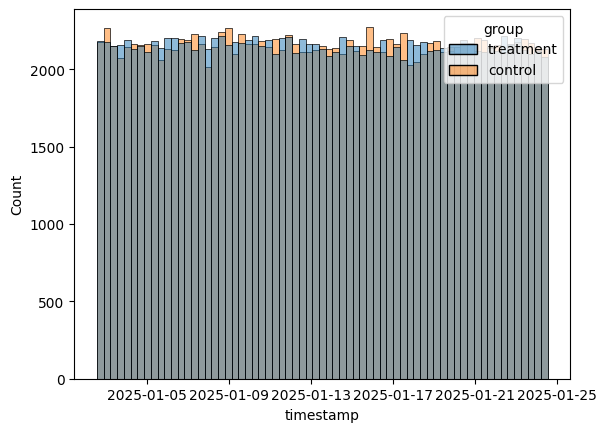

In [ ]:
sns.histplot(data=data_clean, x='timestamp', hue='group')

### Анализ сплита

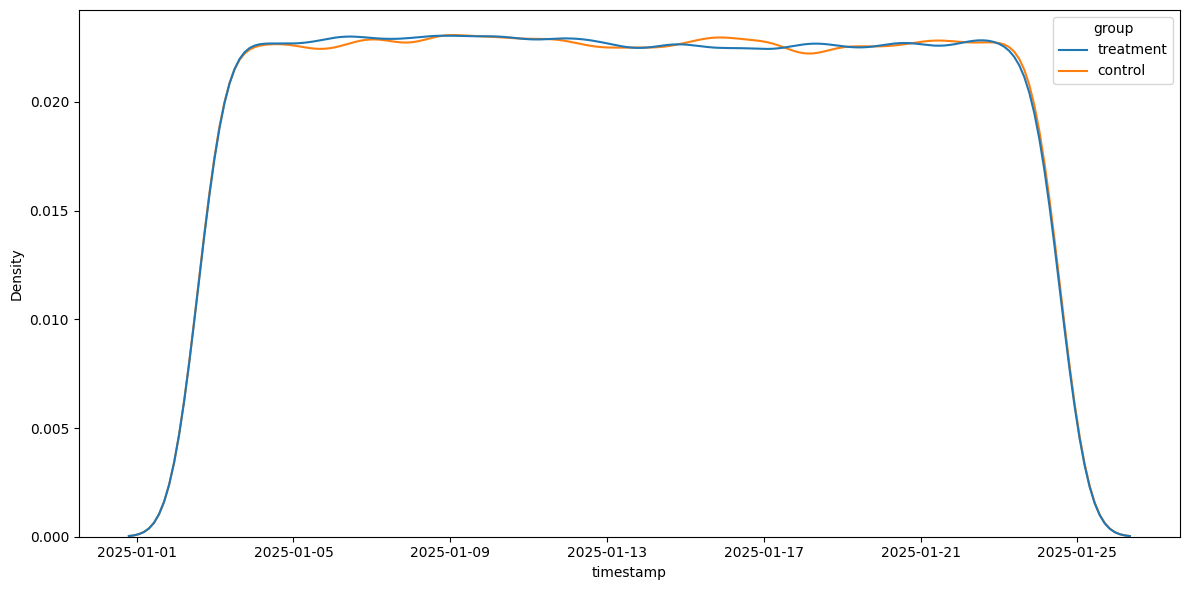

In [ ]:
plt.figure(figsize = (12,6))
sns.kdeplot(data = data_clean, x = 'timestamp', hue = 'group')
plt.tight_layout()

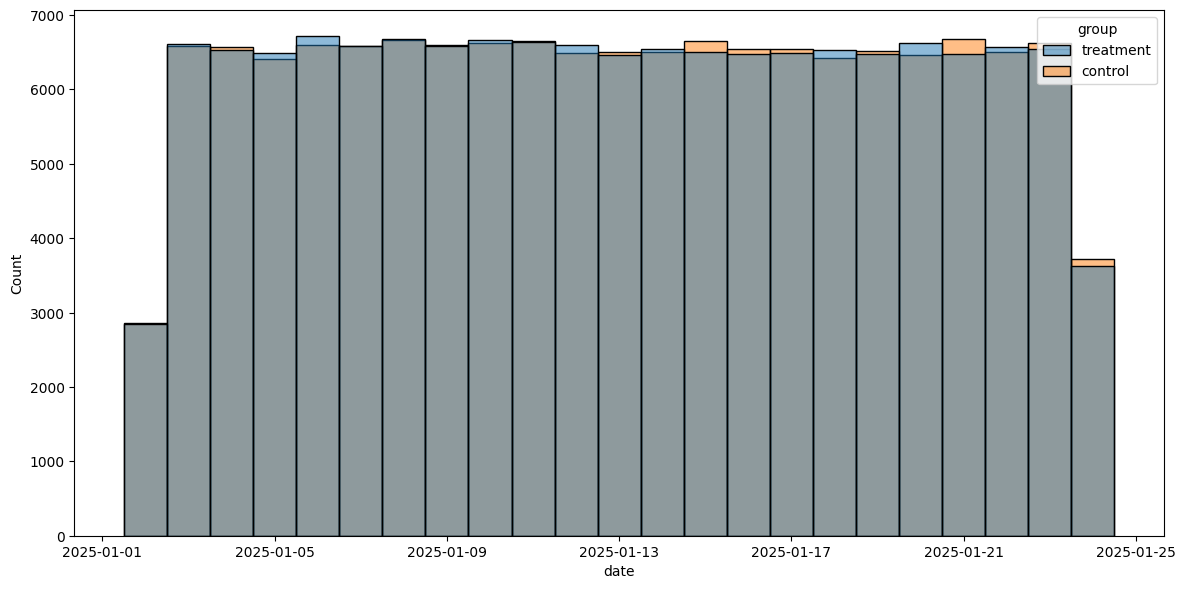

In [ ]:
plt.figure(figsize = (12,6))
sns.histplot(data = data_clean, x = 'date', hue = 'group', bins = 22)
plt.tight_layout()

Средняя разница: 69.09, 0.55%
Максимальная разница: 198, 1.58%
Минимальная разница: 6, 0.05%
Медианная разница: 56.00, 0.45%


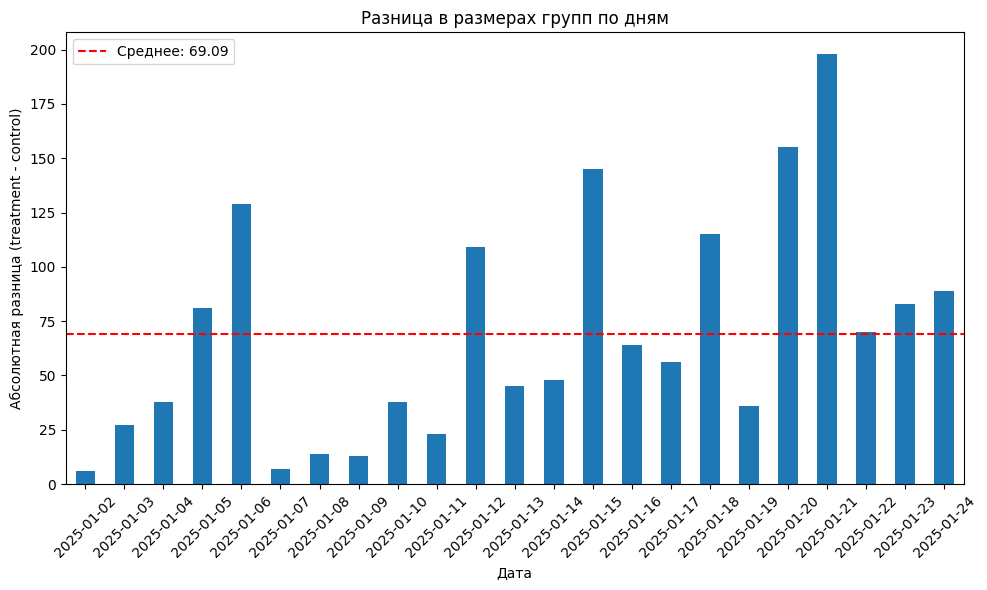

In [ ]:
group_counts = data_clean.groupby(['date', 'group']).size().unstack(fill_value=0)

diffs = (group_counts['treatment'] - group_counts['control']).abs()
mean_diff = diffs.mean()
print(f"Средняя разница: {mean_diff:.2f}, {mean_diff/(np.mean(data_clean.groupby('date').count()))*100:.2f}%")
print(f"Максимальная разница: {diffs.max():.0f}, {diffs.max()/(np.mean(data_clean.groupby('date').count()))*100:.2f}%")
print(f"Минимальная разница: {diffs.min():.0f}, {diffs.min()/(np.mean(data_clean.groupby('date').count()))*100:.2f}%")
print(f"Медианная разница: {diffs.median():.2f}, {diffs.median()/(np.mean(data_clean.groupby('date').count()))*100:.2f}%")

plt.figure(figsize=(10, 6))
diffs.plot(kind='bar')
plt.axhline(y=mean_diff, color='r', linestyle='--', label=f'Среднее: {mean_diff:.2f}')
plt.title('Разница в размерах групп по дням')
plt.xlabel('Дата')
plt.ylabel('Абсолютная разница (treatment - control)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Как видим размеры групп и распределение пользователей по дням приблизительно совпадают в группах

 ### AA-тест

In [ ]:
contr = data_clean[data_clean.group == 'control'].sort_values(by = 'date')
c1 = contr.iloc[:len(contr)//2]
c2 = contr.iloc[len(contr)//2:]

Поделим на два сэмпла по временным промежуткам

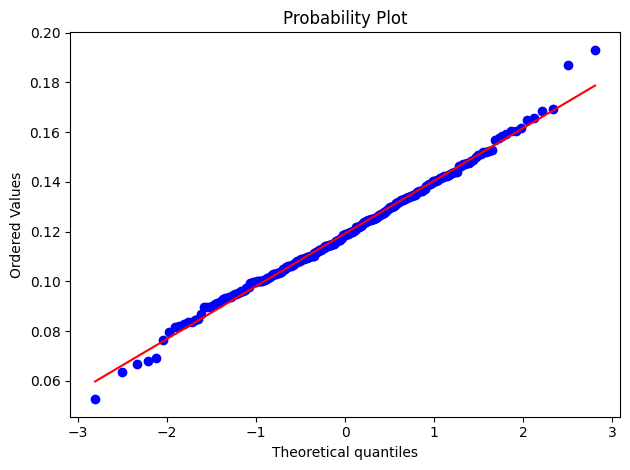

In [ ]:
c1_d = c1.groupby(['date', 'hour']).agg({'user_id':'size', 'converted':'sum'})
c1_d['CR'] = c1_d['converted']/c1_d['user_id']
stats.probplot(c1_d['CR'], dist="norm", plot=plt)
plt.tight_layout()

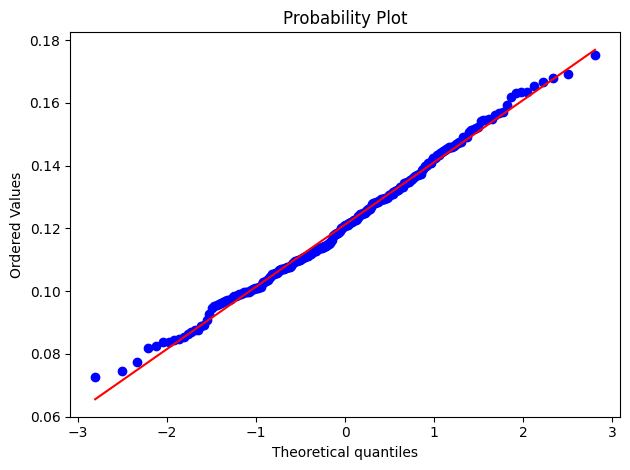

In [ ]:
c2_d = c2.groupby(['date', 'hour']).agg({'user_id':'size', 'converted':'sum'})
c2_d['CR'] = c2_d['converted']/c2_d['user_id']
stats.probplot(c2_d['CR'], dist="norm", plot=plt)
plt.tight_layout()

Распределение близко к нормальному, будем использовать t-тест и chi_square

In [ ]:
t_stat, p_value = ttest_ind(c1_d['CR'], c2_d['CR'], equal_var=True)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -1.1276649832701913
P-value: 0.2599522323333486


p-value > 0.05, нет оснований отвергать нулевую гипотезу

In [ ]:
mu = ((np.sum(c1_d['CR']) + np.sum(c2_d['CR']))/(len(c1_d) + len(c2_d)))
sdc1 = (c1_d['CR'] - mu) ** 2
sdc2 = (c2_d['CR'] - mu) ** 2
var = (np.sum(sdc1) + np.sum(sdc2)) / (len(sdc1) + len(sdc2) - 1)
sigma = np.sqrt(var)

In [ ]:
confidence = 0.975
z = stats.norm.ppf(confidence)
margin = z * sigma
diff = np.abs(c1_d['CR'].mean() - c2_d['CR'].mean())
print(margin)
print(diff)

0.040084770034307764
0.0019610036106906537


|diff| < margin -> различия статистически незначимы

## Анализ гипотезы

H0: Конверсии на старой и новой версии лендинга одинаковы

H1: Конверсии на старой и новой версии лендинга различаются

### Z-test

* Метрика — доля (конверсия), бинарный исход 0/1.

* В каждой группе много наблюдений => биномиальное распределение можно аппроксимировать нормальным.

* Мы сравниваем две пропорции (в control и treatment).

* После очистки данных каждый пользователь учитывается один раз, поэтому наблюдения независимы.

Значит, используем z-тест для разности долей, который основан на нормальной аппроксимации биномиального распределения и позволяет сравнить конверсии в двух независимых группах при больших размерах выборки.

In [ ]:
sample1 = data_clean.loc[data_clean["group"]=="control", "converted"].values
sample2 = data_clean.loc[data_clean["group"]=="treatment","converted"].values

In [ ]:
N1, N2 = sample1.size, sample2.size
mean1, mean2 = sample1.mean(), sample2.mean()
diff = mean2 - mean1

print("N1,N2:", N1, N2)
print("mean1, mean2:", mean1, mean2)
print("diff:", diff)

N1,N2: 144319 144316
mean1, mean2: 0.12039301824430601 0.11869785747942016
diff: -0.0016951607648858502


Для 0/1 среднее = доля единиц. Значит, `mean1` и `mean2` — это p1^ и p2^ (оценки конверсий).

Нас интересует эффект новой версии. Поэтому считаем разницу. Если `diff` > 0 - новая лучше, если `diff` < 0 - хуже.

Получили отрицательный результат, значит новая версия хуже. Однако по одному `diff` нельзя сделать вывод о наличии статистически значимого эффекта, так как наблюдаемая разница может быть обусловлена случайными колебаниями выборки.

In [ ]:
P_pool = (sample1.sum() + sample2.sum()) / (N1 + N2)
se = np.sqrt(P_pool*(1-P_pool)*(1/N1 + 1/N2))

Под H0 предполагается, что обе группы имеют одну истинную конверсию p, просто мы её не знаем. Поэтому считаем оценку общего p^. Берем такую формулу стандартной ошибки, тк для Бернулли в стандартной ошибке при выборочной дисперсии мы еще делим на N. Если посчитать разницу двух независимых долей и взять корень, то мы и получим эту формулу.

In [ ]:
zcrit = st.norm.ppf(0.975) # это критическое значение z для двустороннего теста при a = 0.05
margin = zcrit * se # это половина доверительного интервала вокруг нуля. то есть при верной H0 разница обычно лежит в пределах от -margin до margin

* Если `abs(diff) margin`, то разница выходит за пределы обычного шума. H0 отвергаем.
* Если `abs(diff) <= margin`, то разница укладывается в шум. H0 не отвергаем.

In [ ]:
print("margin:", margin)
print("Are they different? ->", abs(diff) > margin)

z_stat = diff / se # на сколько стандартных ошибок наблюдаемая разница diff ушла от H0
p_val = 2*(1 - st.norm.cdf(abs(z_stat))) # вероятность получить такое же или более экстремальное значение при H0
print("z_stat:", z_stat, "p_val:", p_val)

margin: 0.0023671380246047024
Are they different? -> False
z_stat: -1.4035742794239752 p_val: 0.1604456586524421


Получено `margin = 0.00237`, при этом `abs(diff) > margin -> False`, то есть наблюдаемая разница конверсий не превышает порог статистической значимости.  
По z-тесту: `z_stat = -1.404`, `p_val = 0.160`. Так как `p_val > 0.05`, **нет оснований отвергать H0** о равенстве конверсий в группах control и treatment.  
Знак `z_stat` отрицательный, поэтому конверсия в treatment ниже, однако это отличие статистически незначимо и может быть объяснено случайными колебаниями.


### Хи-квадрат

по статье https://habr.com/ru/companies/ligastavok/articles/718336/

Но перед тем, как его проводить, стоит проверить размер тестовой группы для желаемого минимального статистически значимого изменения

В обоих вариантах вам необходимо указать базовый уровень конверсии, минимальное значение для обнаружения изменения, уровень a (процент раз, когда разница будет обнаружена при условии, что ее нет) и уровень мощности (процент раз, когда будет обнаружено минимальное значение изменения, если оно существует).

In [ ]:
import statsmodels.stats.api as sms

def sample_size_calculator(baseline_rate, minimum_effect, power=0.8, alpha=0.05):

    effect_size = sms.proportion_effectsize(baseline_rate, baseline_rate + minimum_effect)
    sample_size = sms.NormalIndPower().solve_power(effect_size, power=power, alpha=alpha, ratio=1)
    return sample_size

baseline_rate = 0.12  # например, конверсия в контрольной группе
minimum_effect = 0.01 # желаемое изменение (например, увеличение на 2%)

sample_size = sample_size_calculator(baseline_rate, minimum_effect)
print(f'Необходимый размер выборки для каждой группы: {sample_size:.0f}')

Необходимый размер выборки для каждой группы: 17163


ну у нас больше размер выборки (хотя тут желаемый эффект с потолка взят)

In [ ]:
import scipy.stats as stats

A = data_clean.loc[data_clean['group'] == 'control', 'converted'].values
B = data_clean.loc[data_clean['group'] == 'treatment', 'converted'].values
group_A = np.array([np.sum(A), A.size - np.sum(A)])
group_B = np.array([np.sum(B), B.size - np.sum(B)])

chi2, p, dof, ex = stats.chi2_contingency([group_A, group_B], correction=False)

p1 = group_B[0] / group_B.sum()
p2 = group_A[0] / group_A.sum()

lift = p1 / p2

se_p1 = np.sqrt(p1 * (1 - p1) / group_B.sum())
se_p2 = np.sqrt(p2 * (1 - p2) / group_A.sum())
std_error = lift * np.sqrt((se_p1 / p1) ** 2 + (se_p2 / p2) ** 2)

ci = stats.norm.interval(0.95, loc=lift, scale=std_error)

print("Хи-квадрат p-value: ", p)
print("Доверительный интервал изменения (lift): ", ci)

if p < 0.05 and ci[0] > 1:
    print("Вариант B лучше.")
elif p < 0.05 and ci[1] < 1:
    print("Вариант A лучше.")
else:
    print("Статистически значимой разницы нет.")

Хи-квадрат p-value:  0.16044565865244048
Доверительный интервал изменения (lift):  (np.float64(0.9663968650571586), np.float64(1.005442685282115))
Статистически значимой разницы нет.


### T-test

**Проверяем на нормальность распределения по группам**

In [ ]:
# выборки 0/1
sampleA = data_clean[data_clean["group"] == "control"]["converted"].values
sampleB = data_clean[data_clean["group"] == "treatment"]["converted"].values

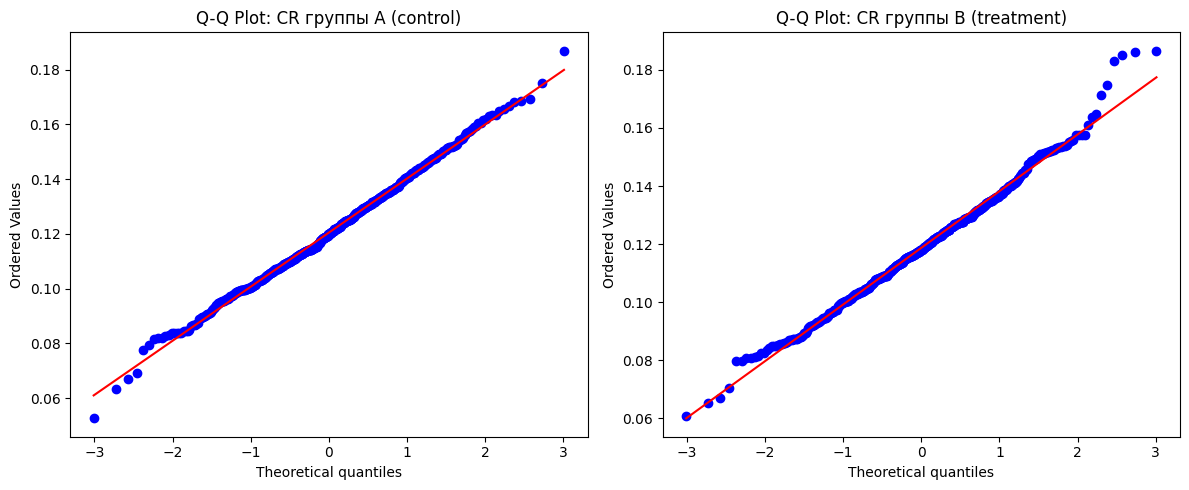

In [ ]:
A = data_clean[data_clean["group"] == "control"].copy()

A_agg = (A.groupby(['date', 'hour']).agg({'user_id': 'size', 'converted': 'sum'}))
A_agg['CR'] = A_agg['converted'] / A_agg['user_id']

B = data_clean[data_clean["group"] == "treatment"].copy()

B_agg = (B.groupby(['date', 'hour']).agg({'user_id': 'size', 'converted': 'sum'}))
B_agg['CR'] = B_agg['converted'] / B_agg['user_id']


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
stats.probplot(A_agg['CR'], dist="norm", plot=plt)
plt.title('Q-Q Plot: CR группы A (control)')

plt.subplot(1, 2, 2)
stats.probplot(B_agg['CR'], dist="norm", plot=plt)
plt.title('Q-Q Plot: CR группы B (treatment)')

plt.tight_layout()
plt.show()

In [ ]:
stat_levene, p_levene = levene(data_clean[data_clean['group'] == 'control']['converted'], data_clean[data_clean['group'] == 'treatment']['converted'])
equal_var = p_levene > 0.05
print(equal_var)


True


In [ ]:
t_stat_scipy, p_value_scipy = ttest_ind(data_clean[data_clean['group'] == 'control']['converted'],
                                        data_clean[data_clean['group'] == 'treatment']['converted'],
                                        equal_var=equal_var, nan_policy='omit')

In [ ]:
print(t_stat_scipy)
print(p_value_scipy)

1.4035742065319463
0.16044675620217255


### Почему все тесты дали одинаковый p-value на наших данных

Метрика `converted` бинарная (0/1), а размеры выборок очень большие. В таком режиме разные тесты фактически проверяют одну и ту же гипотезу и используют одну и ту же нормальную аппроксимацию, поэтому p-value совпадает (или отличается лишь на тысячные доли).

#### 1) Почему совпали t-тест и z-тест
- Среднее = доля единиц = конверсия
- Разница средних = разница конверсий

То есть t-тест, который сравнивает средние, и z-тест, который сравнивает доли, в случае 0/1 сравнивают одну и ту же величину.

Кроме того, при очень больших степенях свободы t-распределение почти не отличимо от нормального.

#### 2) Почему Хи-квадрат совпал с z-тестом
Если представить данные в виде таблицы 2 на 2 (группа на конверсию), то Хи-критерий независимости и z-тест разности долей алгебраически эквивалентны.

А p-value считается по соответствующим распределениям, p-value получается тот же.
